In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("Dataset_B.csv")

targets = ['r1','r2','r3','D1','D2','D3']
feature_cols = [c for c in df.columns if c not in targets]

X = df[feature_cols].values
Y = df[targets].values

In [31]:
# Replace NaNs in X with column means
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

# Remove zero-variance columns (neff repeats)
stds = X.std(axis=0)
mask = stds > 1e-12
X = X[:, mask]
feature_cols = np.array(feature_cols)[mask]

print("Remaining features:", len(feature_cols))

Remaining features: 20


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5948\1402373898.py:2: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(X, axis=0)


In [32]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

Xn = scaler_X.fit_transform(X)
Yn = scaler_Y.fit_transform(Y)

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(
    Xn, Yn, test_size=0.2, random_state=42
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
Y_test_t  = torch.tensor(Y_test, dtype=torch.float32)

In [44]:
class InverseNN(nn.Module):
    def __init__(self, in_dim, out_dim=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim)
        )

    def forward(self, x):
        return self.net(x)

In [45]:
in_dim = X_train.shape[1]
model = InverseNN(in_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 500
best_loss = np.inf
best_model_state = model.state_dict()  # <-- ensures no NameError

In [46]:
loss_curve = []

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()

    y_pred = model(X_train_t)
    loss = criterion(y_pred, Y_train_t)

    # If loss becomes NaN, skip to prevent crash
    if torch.isnan(loss):
        print("⚠️ Loss became NaN — skipping epoch.")
        continue

    loss.backward()
    optimizer.step()
    loss_curve.append(loss.item())

    # Early stopping + best model tracking
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_model_state = model.state_dict()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

print("\nTraining complete. Best loss:", best_loss)
model.load_state_dict(best_model_state)

Epoch 0, Loss = 1.009711
Epoch 20, Loss = 0.608241
Epoch 40, Loss = 0.519894
Epoch 60, Loss = 0.469255
Epoch 80, Loss = 0.438418
Epoch 100, Loss = 0.415356
Epoch 120, Loss = 0.395488
Epoch 140, Loss = 0.381257
Epoch 160, Loss = 0.368283
Epoch 180, Loss = 0.363185
Epoch 200, Loss = 0.350268
Epoch 220, Loss = 0.346475
Epoch 240, Loss = 0.335764
Epoch 260, Loss = 0.331581
Epoch 280, Loss = 0.329361
Epoch 300, Loss = 0.320658
Epoch 320, Loss = 0.315522
Epoch 340, Loss = 0.313520
Epoch 360, Loss = 0.316205
Epoch 380, Loss = 0.304868
Epoch 400, Loss = 0.300984
Epoch 420, Loss = 0.297761
Epoch 440, Loss = 0.294134
Epoch 460, Loss = 0.294646
Epoch 480, Loss = 0.288788

Training complete. Best loss: 0.2855175733566284


<All keys matched successfully>

In [47]:
model.eval()
with torch.no_grad():
    Y_pred_t = model(X_test_t).cpu().numpy()

Y_pred  = scaler_Y.inverse_transform(Y_pred_t)
Y_true  = scaler_Y.inverse_transform(Y_test)

In [48]:
targets = ['r1','r2','r3','D1','D2','D3']

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

for i, t in enumerate(targets):
    rmse = np.sqrt(mean_squared_error(Y_true[:, i], Y_pred[:, i]))
    mae  = mean_absolute_error(Y_true[:, i], Y_pred[:, i])
    r2   = r2_score(Y_true[:, i], Y_pred[:, i])

    print(f"{t}: RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}")

r1: RMSE=0.6541 | MAE=0.4241 | R²=0.6717
r2: RMSE=0.9508 | MAE=0.6915 | R²=0.5601
r3: RMSE=1.2672 | MAE=1.0125 | R²=0.2042
D1: RMSE=0.0022 | MAE=0.0014 | R²=0.9070
D2: RMSE=0.0011 | MAE=0.0007 | R²=0.9756
D3: RMSE=0.0034 | MAE=0.0025 | R²=0.5325


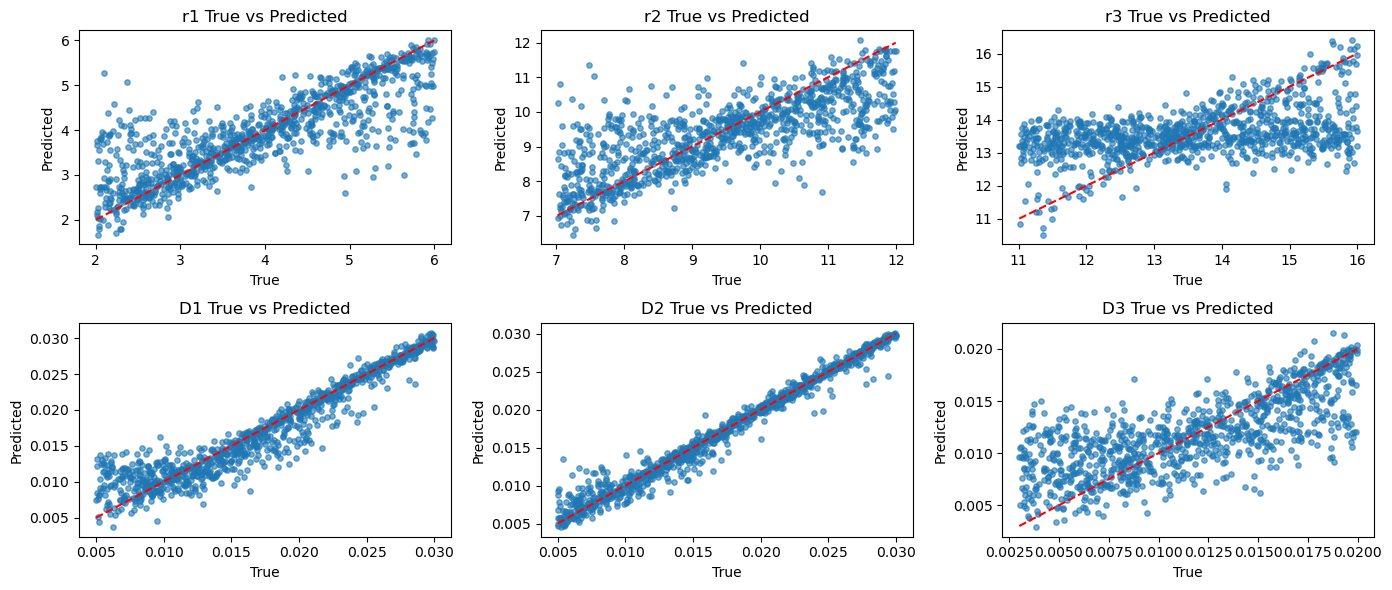

In [49]:
plt.figure(figsize=(14,6))

for i, t in enumerate(targets):
    plt.subplot(2,3,i+1)
    plt.scatter(Y_true[:,i], Y_pred[:,i], s=15, alpha=0.6)
    plt.plot([Y_true[:,i].min(), Y_true[:,i].max()],
             [Y_true[:,i].min(), Y_true[:,i].max()], 'r--')
    plt.title(f"{t} True vs Predicted")
    plt.xlabel("True")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

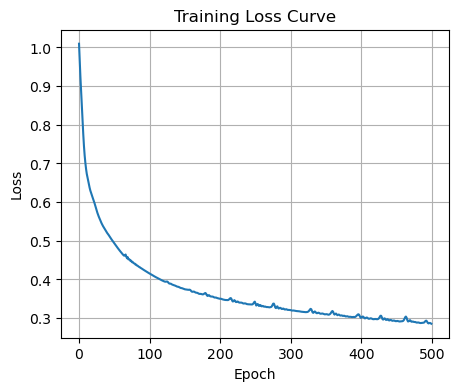

In [50]:
plt.figure(figsize=(5,4))
plt.plot(loss_curve)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [51]:
np.save("true_inverse_B_FFNN_tuned.npy", Y_true)
np.save("pred_inverse_B_FFNN_tuned.npy", Y_pred)